# 4. Modeling

The main clustering model is **K-Means**, applied to the full prepared dataset `X_model`.

Hierarchical clustering is used as a supporting method on a 2,000-customer sample to visually inspect the data structure and inform the choice of K before K-Means is fitted.

The clustering model uses three behavioural variables:

- `DaysSinceLastStay`: measures customer recency.
- `TotalRevenue`: measures customer monetary value for the hotel.
- `Tenure`: measures the length of the relationship between the customer and the hotel.

These variables follow the logic of customer value analysis: recent customers, valuable customers and long-term customers were considered the especially relevant features for this marketing segmentation. All other variables are in `df_profile` and used exclusively for cluster interpretation.

Categorical variables such as `Nationality`, `MarketSegment` and `DistributionChannel` were not used directly in the K-Means model because K-Means is distance-based and works best with numerical variables. Instead, these variables are used after clustering to describe and interpret the segments.

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
import joblib
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.preprocessing import MinMaxScaler as MMS

## 4.1 Load Prepared Data

`X_model` is the MinMaxScaled dataset used for clustering. `X_unscaled` contains the same three variables before scaling and is used for interpretation. `df_profile` contains the full customer-level dataset including all descriptors and is used for business profiling once cluster labels are assigned.

In [2]:
processed_path = "../data/processed"

X_model = pd.read_csv(f"{processed_path}/X_model.csv", index_col=0)
X_unscaled = pd.read_csv(f"{processed_path}/X_unscaled.csv", index_col=0)
df_profile = pd.read_csv(f"{processed_path}/df_profile.csv", index_col=0)

scaler = joblib.load(f"{processed_path}/minmax_scaler.pkl")
model_features = joblib.load(f"{processed_path}/model_features.pkl")

print(f"X_model shape: {X_model.shape}")
print(f"X_unscaled shape: {X_unscaled.shape}")
print(f"df_profile shape: {df_profile.shape}")
print(f"Model features: {model_features}")

title_fs = 14
label_fs = 11
tick_fs  = 9

X_model shape: (60903, 3)
X_unscaled shape: (60903, 3)
df_profile shape: (60903, 18)
Model features: ['DaysSinceLastStay', 'TotalRevenue', 'Tenure']


## 4.2 Hierarchical Clustering

Before fitting the final K-Means model, hierarchical clustering was used as an exploratory step. Since the full dataset is too large for hierarchical clustering, a random sample of 2,000 customers was used.

Ward linkage was selected because it tries to create compact groups by minimising within-cluster variance.

### 4.2.1 Dendrogram

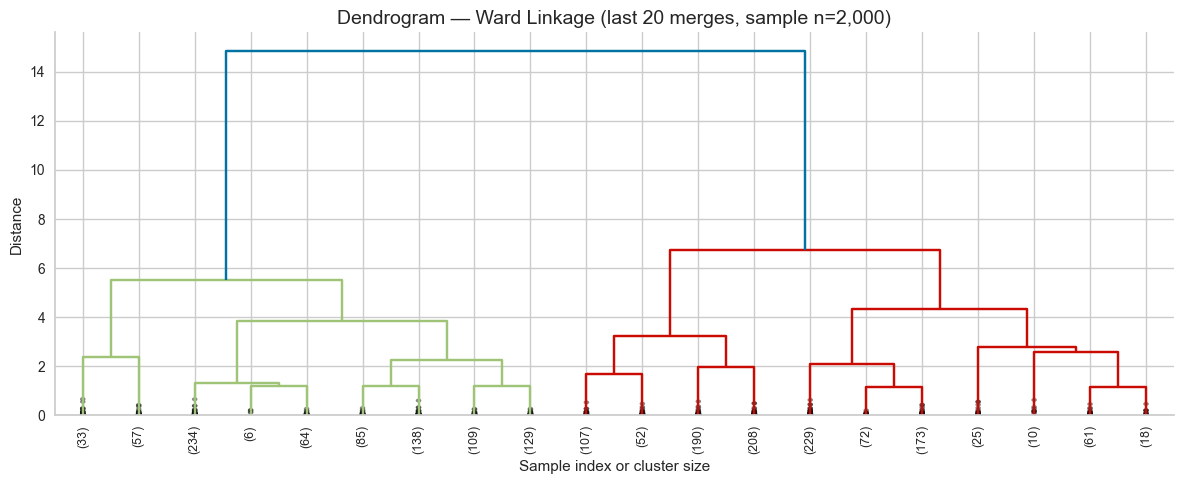

In [3]:
# creating the sample
X_sample = X_model.sample(n=2000, random_state=123)

Z_ward = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    Z_ward,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90,
    leaf_font_size=tick_fs,
    show_contracted=True,
    ax=ax
)
ax.set_title('Dendrogram — Ward Linkage (last 20 merges, sample n=2,000)', fontsize=title_fs)
ax.set_xlabel('Sample index or cluster size', fontsize=label_fs)
ax.set_ylabel('Distance', fontsize=label_fs)
sns.despine()
plt.tight_layout()
plt.show()

#### Key Findings:

The dendrogram shows two main branches, meaning that the strongest split in the sample is between two broad customer groups. However, each branch is also divided into smaller groups, which suggests that more than two clusters may also be reasonable. Since the dendrogram is based only on a sample, it is not used alone to choose the final number of clusters. It is used as an initial visual guide before testing different K values with K-Means.

## 4.3 K-Means Clustering

K-Means was then applied to the full prepared dataset. Several values of K were tested.

## 4.3.1 Evaluate K values

K values from 3 to 7 were tested. The comparison includes inertia, silhouette score, Davies-Bouldin score, Calinski-Harabasz score and cluster size balance.

In [4]:
K_range = range(3, 8)

results = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_model)
    
    cluster_sizes = pd.Series(labels).value_counts(normalize=True)
    
    results.append({
        "K": k,
        "Inertia": km.inertia_,
        "Silhouette": silhouette_score(X_model, labels, sample_size=10000, random_state=123),
        "Davies-Bouldin": davies_bouldin_score(X_model, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_model, labels),
        "Smallest cluster (%)": cluster_sizes.min() * 100,
        "Largest cluster (%)": cluster_sizes.max() * 100
    })

k_results = pd.DataFrame(results).round(4)
display(k_results)

,K,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz,Smallest cluster (%),Largest cluster (%)
0,3,1968.6893,0.4271,0.8903,64353.0785,31.6602,34.4778
1,4,1374.0137,0.4621,0.7743,70254.7826,5.9390,32.2447
2,5,1186.5735,0.4661,0.8276,63418.5895,4.8076,31.2792
3,6,1030.8612,0.3841,0.8800,60237.2485,4.4070,25.1186
4,7,914.9981,0.3809,0.8669,57838.4883,2.2363,24.6310


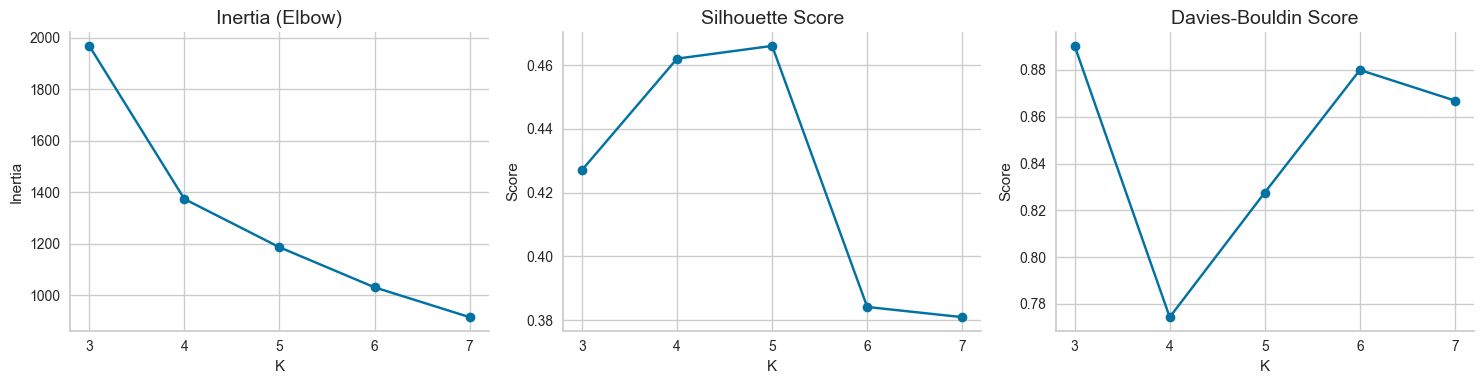

In [5]:
# visualizing the plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_results["K"], k_results["Inertia"], "o-")
axes[0].set_title("Inertia (Elbow)", fontsize=title_fs)
axes[0].set_xlabel("K", fontsize=label_fs)
axes[0].set_ylabel("Inertia", fontsize=label_fs)
axes[0].set_xticks(list(K_range))

axes[1].plot(k_results["K"], k_results["Silhouette"], "o-")
axes[1].set_title("Silhouette Score", fontsize=title_fs)
axes[1].set_xlabel("K", fontsize=label_fs)
axes[1].set_ylabel("Score", fontsize=label_fs)
axes[1].set_xticks(list(K_range))

axes[2].plot(k_results["K"], k_results["Davies-Bouldin"], "o-")
axes[2].set_title("Davies-Bouldin Score", fontsize=title_fs)
axes[2].set_xlabel("K", fontsize=label_fs)
axes[2].set_ylabel("Score", fontsize=label_fs)
axes[2].set_xticks(list(K_range))

sns.despine()
plt.tight_layout()
plt.show()

#### Key Findings:

- The elbow plot shows that inertia decreases as K increases. 

- The biggest decrease happens from K=3 to K=4, but after that the improvement becomes smaller. Therefore, maybe K=4 may is a possible option from the elbow method.

- The silhouette score is highest for K=5, but K=4 is very close. Both K=4 and K=5 perform better than K=3 in this metric.

- The Davies-Bouldin score is lowest for K=4, which means K=4 has the best cluster separation according to this metric.

- However, K=4 and K=5 create very small clusters, with the smallest cluster representing only about 5.9% and 4.8% of customers. This might make the segmentation less balanced and less useful for marketing strategy.

## 4.3.2 Comparing K=3 and K=4

Since this is a marketing segmentation project, the final choice should not be based only on metrics. The clusters also need to be understandable and useful for business decisions.

For this reason, K=3 and K=4 are compared through their cluster profiles.

In [6]:
models_to_compare = [3, 4]
comparison_results = []

for k in models_to_compare:
    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_model)
    
    cluster_sizes = pd.Series(labels).value_counts(normalize=True)
    
    comparison_results.append({
        "K": k,
        "Inertia": km.inertia_,
        "Silhouette": silhouette_score(X_model, labels, sample_size=10000, random_state=123),
        "Davies-Bouldin": davies_bouldin_score(X_model, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_model, labels),
        "Smallest cluster (%)": cluster_sizes.min() * 100,
        "Largest cluster (%)": cluster_sizes.max() * 100
    })

k3_k4_comparison = pd.DataFrame(comparison_results).round(4)
display(k3_k4_comparison)

,K,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz,Smallest cluster (%),Largest cluster (%)
0,3,1968.6893,0.4271,0.8903,64353.0785,31.6602,34.4778
1,4,1374.0137,0.4621,0.7743,70254.7826,5.9390,32.2447


#### Key Findings

K=4 performs better than K=3 in the main clustering metrics.

Compared with K=3, K=4 has:

- lower inertia: 1374.01 vs 1968.69
- higher silhouette score: 0.4621 vs 0.4271
- lower Davies-Bouldin score: 0.7743 vs 0.8903
- higher Calinski-Harabasz score: 70254.78 vs 64353.08

This means that K=4 creates better-separated and more compact clusters than K=3.

However, K=4 creates one smaller cluster, representing only 5.94% of customers. This is not automatically a problem, because a small cluster can still be useful if it represents a valuable customer group.

Therefore, K=3 and K=4 will be compared through cluster profiling before selecting the final solution.

In [7]:
# variables used to describe the clusters
profile_cols = [
    "DaysSinceLastStay",
    "TotalRevenue",
    "Tenure",
    "BookingsCheckedIn",
    "AverageLeadTime",
    "RoomNights"
]

profile_cols = [col for col in profile_cols if col in df_profile.columns]


# profiling K=3
kmeans_3 = KMeans(n_clusters=3, random_state=123, n_init=10)
labels_3 = kmeans_3.fit_predict(X_model)

df_profile_k3 = df_profile.copy()
df_profile_k3["Cluster_K3"] = labels_3

k3_sizes = (
    df_profile_k3["Cluster_K3"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

k3_sizes["Percentage"] = (
    k3_sizes["Count"] / k3_sizes["Count"].sum() * 100
).round(2)

display(k3_sizes)

k3_profile = (
    df_profile_k3
    .groupby("Cluster_K3")[profile_cols]
    .mean()
    .round(2)
)

display(k3_profile)

,Count,Percentage
Cluster_K3,,
0,20623,33.86
1,19282,31.66
2,20998,34.48


,DaysSinceLastStay,TotalRevenue,Tenure,BookingsCheckedIn,AverageLeadTime,RoomNights
Cluster_K3,,,,,,
0,177.61,537.25,12.66,1.11,83.40,3.32
1,888.34,409.72,0.78,1.03,79.12,2.99
2,537.69,484.17,3.63,1.04,98.55,3.17


In [8]:
# profiling K=4
kmeans_4 = KMeans(n_clusters=4, random_state=123, n_init=10)
labels_4 = kmeans_4.fit_predict(X_model)

df_profile_k4 = df_profile.copy()
df_profile_k4["Cluster_K4"] = labels_4

k4_sizes = (
    df_profile_k4["Cluster_K4"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

k4_sizes["Percentage"] = (
    k4_sizes["Count"] / k4_sizes["Count"].sum() * 100
).round(2)

display(k4_sizes)

k4_profile = (
    df_profile_k4
    .groupby("Cluster_K4")[profile_cols]
    .mean()
    .round(2)
)

display(k4_profile)

,Count,Percentage
Cluster_K4,,
0,18664,30.65
1,18984,31.17
2,19638,32.24
3,3617,5.94


,DaysSinceLastStay,TotalRevenue,Tenure,BookingsCheckedIn,AverageLeadTime,RoomNights
Cluster_K4,,,,,,
0,891.40,387.58,0.77,1.03,79.71,2.96
1,177.89,434.50,8.34,1.07,82.60,3.02
2,541.45,403.28,2.96,1.03,97.46,2.98
3,396.76,1588.15,33.59,1.37,95.45,6.00


#### Key Findings

The K=4 solution creates three large clusters and one smaller cluster.

Clusters 0, 1 and 2 are similar in size, each representing around 31–32% of the customers. Cluster 3 is much smaller, representing 5.94% of customers.

The cluster profiles show that K=4 is not only separating customers by recency, but also by customer value.

- **Cluster 0** has the highest `DaysSinceLastStay` and low revenue. These are the most inactive customers.
- **Cluster 1** has the lowest `DaysSinceLastStay`, meaning these are the most recent customers.
- **Cluster 2** has an intermediate `DaysSinceLastStay`, meaning these customers are less recent than Cluster 1 but not as inactive as Cluster 0.
- **Cluster 3** is clearly different from all other clusters. It has much higher `TotalRevenue`, the longest `Tenure`, more `RoomNights` and more `BookingsCheckedIn`.

Although Cluster 3 is small, it is highly relevant for marketing because it represents a high-value loyal customer group.

For this reason, K=4 adds useful business insight compared with K=3 and is selected as the final clustering solution.

## 4.3.3 Final K-Means Model

The model is fitted again with K=4 so that the final cluster labels can be attached to `df_profile` and `X_unscaled`. These labels will be used in the following sections for cardinality, magnitude, silhouette analysis and business profiling.

In [9]:
K = 4

kmeans = KMeans(n_clusters=K, random_state=123, n_init=10)

all_distances = kmeans.fit_transform(X_model)
cluster_labels = kmeans.predict(X_model)

print(f"K-Means with K={K}")
print(f"Inertia: {kmeans.inertia_:,.0f}")
print(f"Silhouette score: {silhouette_score(X_model, cluster_labels, sample_size=10000, random_state=123):.4f}")
print(f"Davies-Bouldin: {davies_bouldin_score(X_model, cluster_labels):.4f}")

# attach final labels to interpretation datasets
df_profile["Cluster"] = cluster_labels
X_unscaled["Cluster"] = cluster_labels

cluster_size_table = (
    pd.Series(cluster_labels)
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

cluster_size_table["Percentage"] = (
    cluster_size_table["Count"] / cluster_size_table["Count"].sum() * 100
).round(2)

display(cluster_size_table)

K-Means with K=4
Inertia: 1,374
Silhouette score: 0.4621
Davies-Bouldin: 0.7743


,Count,Percentage
0,18664,30.65
1,18984,31.17
2,19638,32.24
3,3617,5.94


## 4.3.4 Cardinality and Magnitude

### Cardinality

In [10]:
cardinality = (
    df_profile["Cluster"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

cardinality["Percentage"] = (
    cardinality["Count"] / cardinality["Count"].sum() * 100
).round(2)

display(cardinality)

,Count,Percentage
Cluster,,
0,18664,30.65
1,18984,31.17
2,19638,32.24
3,3617,5.94


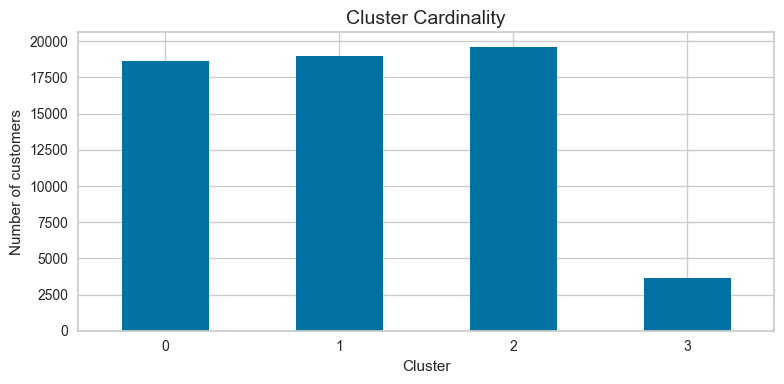

In [11]:
# plotting cluster cardinality

fig, ax = plt.subplots(figsize=(8, 4))

cardinality["Count"].plot(kind="bar", ax=ax)

ax.set_title("Cluster Cardinality", fontsize=title_fs)
ax.set_xlabel("Cluster", fontsize=label_fs)
ax.set_ylabel("Number of customers", fontsize=label_fs)
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

#### Key Findings:

The cardinality table and plot show that the K=4 solution creates three large clusters and one smaller cluster.

Clusters 0, 1 and 2 are similar in size:

- Cluster 0: 18,664 customers, representing 30.65%
- Cluster 1: 18,984 customers, representing 31.17%
- Cluster 2: 19,638 customers, representing 32.24%

Cluster 3 is much smaller, with 3,617 customers, representing 5.94% of the dataset.

### Magnitude

In [12]:
dist_to_assigned_centroid = all_distances[np.arange(len(cluster_labels)), cluster_labels]

magnitude = (
    pd.DataFrame({
        "Cluster": cluster_labels,
        "DistanceToCentroid": dist_to_assigned_centroid
    })
    .groupby("Cluster")["DistanceToCentroid"]
    .mean()
    .to_frame("Average distance to centroid")
    .round(4)
)

display(magnitude)

,Average distance to centroid
Cluster,
0,0.1184
1,0.1225
2,0.1143
3,0.2750


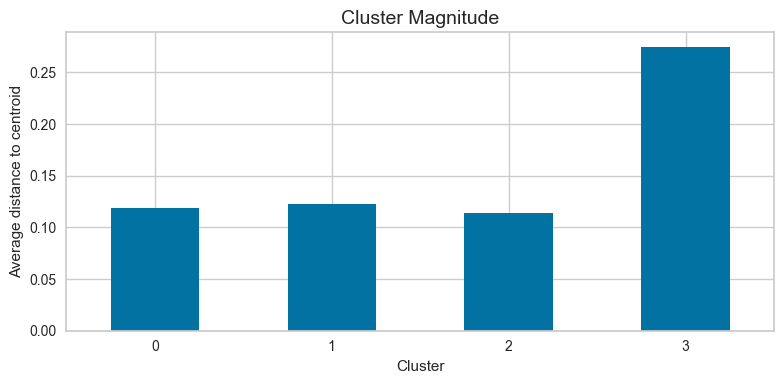

In [13]:
# plotting cluster magnitude

fig, ax = plt.subplots(figsize=(8, 4))

magnitude["Average distance to centroid"].plot(kind="bar", ax=ax)

ax.set_title("Cluster Magnitude", fontsize=title_fs)
ax.set_xlabel("Cluster", fontsize=label_fs)
ax.set_ylabel("Average distance to centroid", fontsize=label_fs)
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

#### Key Findings

The magnitude table and plot show that Clusters 0, 1 and 2 are relatively compact. Their average distances to the centroid are very similar:

- Cluster 0: 0.1184
- Cluster 1: 0.1225
- Cluster 2: 0.1143

Cluster 3 has a higher average distance to the centroid, with a value of 0.2750. This means that customers in Cluster 3 are more varied than customers in the other clusters.

This result is expected because Cluster 3 represents high-value loyal customers. These customers share a similar overall profile, but they may differ in how much revenue they generated, how long their relationship with the hotel is, or how many nights they stayed.

Therefore, Cluster 3 is less compact than the other clusters, but it still has a clear business meaning and will be kept in the final segmentation.

## 4.3.5 Silhouette Plot

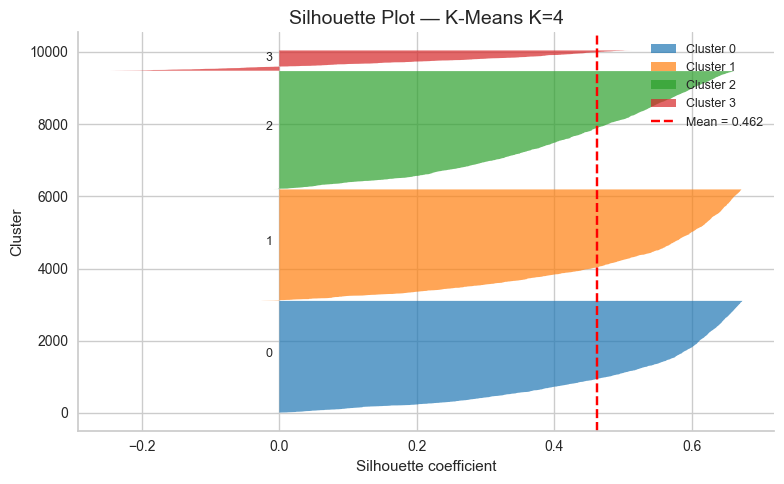

In [14]:
sample_idx = X_model.sample(n=10000, random_state=123).index

X_sil = X_model.loc[sample_idx]
labels_sil = pd.Series(cluster_labels, index=X_model.index).loc[sample_idx].values

sil_vals = silhouette_samples(X_sil, labels_sil)

fig, ax = plt.subplots(figsize=(8, 5))

y_lower = 10
colors = sns.color_palette("tab10", K)

for i in range(K):
    cluster_sil = np.sort(sil_vals[labels_sil == i])
    size = cluster_sil.shape[0]
    y_upper = y_lower + size

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_sil,
        facecolor=colors[i],
        alpha=0.7,
        label=f"Cluster {i}"
    )

    ax.text(-0.02, y_lower + 0.5 * size, str(i), fontsize=tick_fs)
    y_lower = y_upper + 10

avg_sil = sil_vals.mean()

ax.axvline(
    x=avg_sil,
    color="red",
    linestyle="--",
    label=f"Mean = {avg_sil:.3f}"
)

ax.set_title(f"Silhouette Plot — K-Means K={K}", fontsize=title_fs)
ax.set_xlabel("Silhouette coefficient", fontsize=label_fs)
ax.set_ylabel("Cluster")
ax.legend(loc="upper right", fontsize=tick_fs)

sns.despine()
plt.tight_layout()
plt.show()

#### Key Findings

- The silhouette plot shows that most customers have positive silhouette values. Clusters 0, 1 and 2 show good separation, with many customers above the average silhouette line of 0.462.

- Cluster 3 is smaller and less stable than the other clusters. It includes some negative silhouette values, meaning that some customers in this group are close to the boundary with another cluster. However, Cluster 3 is still kept.

## 4.4 Cluster Analysis

The cluster labels are cross-referenced with `df_profile` to build a complete picture of each segment. The analysis moves from the clustering variables themselves (mean, median, min, max) to the descriptor variables not used in clustering (booking channel, market segment, nationality, room preferences, age).

### 4.4.1 Mean Values per Cluster

In [15]:
numeric_profile_cols = [
    "DaysSinceLastStay",
    "TotalRevenue",
    "Tenure",
    "BookingsCheckedIn",
    "AverageLeadTime",
    "RoomNights"
]

numeric_profile_cols = [col for col in numeric_profile_cols if col in df_profile.columns]

cluster_mean = (
    df_profile
    .groupby("Cluster")[numeric_profile_cols]
    .mean()
    .round(2)
)

cluster_mean["Size"] = df_profile.groupby("Cluster").size()
cluster_mean["Pct (%)"] = (cluster_mean["Size"] / len(df_profile) * 100).round(1)

display(cluster_mean)

,DaysSinceLastStay,TotalRevenue,Tenure,BookingsCheckedIn,AverageLeadTime,RoomNights,Size,Pct (%)
Cluster,,,,,,,,
0,891.40,387.58,0.77,1.03,79.71,2.96,18664,30.6
1,177.89,434.50,8.34,1.07,82.60,3.02,18984,31.2
2,541.45,403.28,2.96,1.03,97.46,2.98,19638,32.2
3,396.76,1588.15,33.59,1.37,95.45,6.00,3617,5.9


#### Key Findings

- **Cluster 0** has the highest `DaysSinceLastStay` at 891.40 days and the lowest `TotalRevenue` at 387.58. This suggests that these are the most inactive and lowest-value customers.

- **Cluster 1** has the lowest `DaysSinceLastStay` at 177.89 days. These are the most recent customers, with moderate revenue and some relationship with the hotel.

- **Cluster 2** has an intermediate `DaysSinceLastStay` at 541.45 days. These customers are less recent than Cluster 1, but not as inactive as Cluster 0. Their revenue and tenure are also relatively low.

- **Cluster 3** is clearly the most valuable segment. It has much higher `TotalRevenue` at 1,588.15, the longest `Tenure` at 33.59, the highest `BookingsCheckedIn` at 1.37 and the highest `RoomNights` at 6.00.

### 4.4.2 Median Values per Cluster

In [16]:
cluster_median = (
    df_profile
    .groupby("Cluster")[numeric_profile_cols]
    .median()
    .round(2)
)

display(cluster_median)

,DaysSinceLastStay,TotalRevenue,Tenure,BookingsCheckedIn,AverageLeadTime,RoomNights
Cluster,,,,,,
0,889.0,328.26,0.0,1.0,53.0,3.0
1,181.0,399.00,0.0,1.0,60.0,3.0
2,544.0,369.00,0.0,1.0,64.0,3.0
3,403.0,1476.00,0.0,1.0,75.0,5.0


#### Key Findings

- **Cluster 0** has the highest median `DaysSinceLastStay` at 889 days. This confirms that these customers are the most inactive.

- **Cluster 1** has the lowest median `DaysSinceLastStay` at 181 days. This confirms that these are the most recent customers.

- **Cluster 2** has an intermediate median `DaysSinceLastStay` at 544 days. These customers are between the active and dormant groups.

- **Cluster 3** has the highest median `TotalRevenue` at 1,476 and the highest median `RoomNights` at 5. This confirms that this is the most valuable customer segment.

### 4.4.3 Min and Max of Clustering Variables per Cluster

The min and max values show the full range of each cluster across the three variables used in clustering. They help check how clearly the clusters are separated and where there might be overlap between neighbouring groups.

In [17]:
model_cols = ["DaysSinceLastStay", "TotalRevenue", "Tenure"]

cluster_min_max = (
    df_profile
    .groupby("Cluster")[model_cols]
    .agg(["min", "max"])
    .round(2)
)

display(cluster_min_max)

DaysSinceLastStay       TotalRevenue          Tenure      
                      min   max          min      max    min   max
Cluster                                                           
0                     714  1104          0.0  1774.00      0   454
1                       0   369          0.0  1233.00      0  1100
2                     355   720          0.0  1147.90      0   700
3                       1  1081        908.2  2490.36      0  1046

#### Key Findings:

The four clusters separate mainly along **recency**, but K=4 also identifies a clear **high-value loyal segment** based on revenue, tenure, room nights and bookings:

- **Cluster 1 — Active Guests** (31%): last stay between 0 and 369 days ago, average revenue of €434.50 and mean tenure of 8.34 days. These are the most recently active customers and should be considered an important retention segment.

- **Cluster 2 — Lapsed Guests** (32%): last stay between 355 and 720 days ago, average revenue of €403.28 and mean tenure of 2.96 days. These customers are in the mid-recency window: they have not stayed recently, but they are not as inactive as the dormant group.

- **Cluster 0 — Dormant Guests** (31%): last stay between 714 and 1,104 days ago, lowest average revenue of €387.58 and mean tenure of 0.77 days. These are the least engaged customers, with no recent relationship with the hotel.

- **Cluster 3 — High-Value Loyal Guests** (6%): average revenue of €1,588.15, mean tenure of 33.59 days, highest average room nights and highest average bookings checked in. Although this is the smallest segment, it is the most valuable and has a clear business meaning.

There is some overlap in `DaysSinceLastStay`, especially between neighbouring clusters. However, Cluster 3 is clearly separated by `TotalRevenue`, confirming its importance as a representation of high-value loyal customers.

### 4.4.4 Categorical Descriptors by Cluster

Market segment, distribution channel, and nationality are cross-referenced here to describe the composition of each segment and support the marketing interpretation.

In [18]:
cat_cols = ["MarketSegment", "DistributionChannel"]

for col in cat_cols:
    if col in df_profile.columns:
        print(f"\n{col} distribution by cluster (%)")
        table = pd.crosstab(
            df_profile["Cluster"],
            df_profile[col],
            normalize="index"
        ).mul(100).round(1)
        display(table)


MarketSegment distribution by cluster (%)


MarketSegment,Aviation,Complementary,Corporate,Direct,Groups,Other,Travel Agent/Operator
Cluster,,,,,,,
0,0.2,0.6,2.5,9.9,12.1,55.5,19.1
1,0.4,0.9,3.9,14.2,14.2,54.4,11.9
2,0.2,0.3,1.8,12.0,12.1,57.9,15.6
3,1.2,0.0,4.1,21.4,11.2,57.6,4.4



DistributionChannel distribution by cluster (%)


DistributionChannel,Corporate,Direct,Electronic Distribution,Travel Agent/Operator
Cluster,,,,
0,4.0,10.6,0.4,85.0
1,3.7,14.9,1.1,80.3
2,2.2,12.4,0.8,84.6
3,5.2,21.3,0.5,73.0


#### Key Findings:

- **Market Segment**: all clusters are dominated by the `Other` segment, representing around 54% to 58% of customers in each cluster. This means that market segment alone does not explain the differences between the customer groups.

- **Cluster 3 — High-Value Loyal Guests** has the highest share of `Direct` customers in MarketSegment, with 21.4%, and the lowest share of `Travel Agent/Operator`, with 4.4%. This suggests that high-value loyal customers are more likely to have a direct relationship with the hotel.

- **Distribution Channel**: all clusters are still mostly dominated by `Travel Agent/Operator`, especially Clusters 0, 1 and 2, where this channel represents around 80% to 85% of customers.

- **Cluster 3 — High-Value Loyal Guests** again stands out. It has the highest share of `Direct` distribution, with 21.3%, and the lowest share of `Travel Agent/Operator`, with 73.0%.

In [19]:
# nationality top 5 per cluster
print("Top 5 nationalities per cluster:")

for c in sorted(df_profile["Cluster"].unique()):
    top = (
        df_profile[df_profile["Cluster"] == c]["Nationality"]
        .value_counts(normalize=True)
        .head(5)
        .mul(100)
        .round(1)
    )

    print(f"\nCluster {c}:")
    display(top.rename("% of cluster"))

Top 5 nationalities per cluster:

Cluster 0:


Nationality
PRT      19.9
FRA      16.6
DEU      12.7
Other    10.3
GBR       7.7
Name: % of cluster, dtype: float64


Cluster 1:


Nationality
FRA      13.2
Other    12.8
PRT      12.7
DEU      11.9
GBR      11.2
Name: % of cluster, dtype: float64


Cluster 2:


Nationality
FRA      14.7
DEU      13.5
PRT      12.3
GBR      12.2
Other    11.4
Name: % of cluster, dtype: float64


Cluster 3:


Nationality
Other    16.6
FRA      16.0
DEU      11.4
GBR      10.1
PRT       9.3
Name: % of cluster, dtype: float64

#### Key Findings:

- **Cluster 0 — Dormant Guests** has the highest share of Portuguese customers, with PRT representing 19.9% of the cluster. This suggests that domestic customers are more present in the dormant segment.

- **Cluster 1 — Active Guests** is more mixed, with FRA, Other, PRT, DEU and GBR all appearing with similar proportions. No single nationality clearly dominates this cluster.

- **Cluster 2 — Lapsed Guests** is also mixed, with FRA, DEU, PRT and GBR appearing in similar proportions.

- **Cluster 3 — High-Value Loyal Guests** has a slightly different composition, with `Other` and FRA as the two largest groups. PRT has the lowest share in this cluster, with 9.3%.

In [20]:
# SR flags and age bin
sr_cols_keep = ["SRHighFloor", "SRKingSizeBed", "SRTwinBed", "SRQuietRoom"]
sr_cols_keep = [col for col in sr_cols_keep if col in df_profile.columns]

sr_profile = (
    df_profile
    .groupby("Cluster")[sr_cols_keep]
    .mean()
    .mul(100)
    .round(1)
)

sr_profile.columns = [col + " (%)" for col in sr_profile.columns]

display(sr_profile)

,SRHighFloor (%),SRKingSizeBed (%),SRTwinBed (%),SRQuietRoom (%)
Cluster,,,,
0,4.0,35.6,13.9,6.4
1,4.9,36.4,14.0,9.0
2,4.4,33.1,13.1,10.0
3,6.2,36.9,16.0,13.3


#### Key Findings:

The special request variables are broadly similar across the four clusters, so they are not the main factors separating the segments.

- **King size bed** is the most common special request in all clusters, ranging from 33.1% to 36.9%. This preference is consistent across the customer base.

- **Twin bed** requests are also relatively stable, ranging from 13.1% to 16.0%.

- **Cluster 3 — High-Value Loyal Guests** shows slightly higher request rates across all special request variables. It has the highest share of high floor requests, twin bed requests and quiet room requests.

- **Quiet room requests** are highest in Cluster 3, at 13.3%, compared with 6.4% in Cluster 0, 9.0% in Cluster 1 and 10.0% in Cluster 2.

## 4.5 Segment Naming

Each cluster was assigned a business label based on the final cluster profiles.

| Cluster | Label | Recency | Avg Revenue | Tenure | Size |
|---------|-------|---------|-------------|--------|------|
| 0 | **Dormant Guests** | 714–1,104 days | €387.58 | 0.77 days | 30.6% |
| 1 | **Active Guests** | 0–369 days | €434.50 | 8.34 days | 31.2% |
| 2 | **Lapsed Guests** | 355–720 days | €403.28 | 2.96 days | 32.2% |
| 3 | **High-Value Loyal Guests** | 1–1,081 days | €1,588.15 | 33.59 days | 5.9% |

In [21]:
# attach readable segment names
segment_names = {
    0: "Dormant Guests",
    1: "Active Guests",
    2: "Lapsed Guests",
    3: "High-Value Loyal Guests"
}

df_profile["Segment"] = df_profile["Cluster"].map(segment_names)

print("Final segment distribution:")

segment_distribution = pd.DataFrame({
    "Count": df_profile["Segment"].value_counts(),
    "Pct (%)": df_profile["Segment"].value_counts(normalize=True).mul(100).round(1)
})

display(segment_distribution)

Final segment distribution:


,Count,Pct (%)
Segment,,
Lapsed Guests,19638,32.2
Active Guests,18984,31.2
Dormant Guests,18664,30.6
High-Value Loyal Guests,3617,5.9
